# 05c – Ensemble: NYC Citi Bike

**Worked on by:** Andreas Schellekens (out-of-fold predictions, ensemble weight, drift-correction test, evaluation, deployable ensemble)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `05a_model_gradient_boosting.ipynb` and `05b_model_huber.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Goal and setup

05a (gradient boosting) and 05b (Huber regression) are two very different models: trees that cut the weather into many small regions, and one straight-line formula with a robust loss. 05b ended with the observation that they seem to make different errors: the trees handle the details of rain and temperature better, the linear model the big holidays. If their errors are not the same, the **average** of the two should be better than either. This notebook tests that, chooses the weight of each model on the yearly folds, and tests one idea against the drift that every model showed (03-05b): correcting a prediction by the model's error in the most recently published months.

Setup: the same libraries, chart style, dataset description and protocol helpers as 05a/05b. The two members are **loaded from their saved files** and copied with `clone` (same settings, not fitted), so this notebook uses exactly the tuned models of 05a and 05b without repeating their code.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

NOTEBOOK = "05c_model_ensemble"
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "citibike_ensemble.joblib"
METRICS_PATH = MODEL_DIR / "metrics.csv"
CV_YEARS = [2016, 2017, 2018, 2019, 2022, 2023]
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


def trips_mape(actual_log_ratio, predicted_log_ratio):
    return np.mean(np.abs(np.expm1(predicted_log_ratio - actual_log_ratio))) * 100


def evaluate(name, split, actual, predicted):
    error = predicted - actual
    has_trips = actual > 0
    percentage = error[has_trips] / actual[has_trips] * 100
    return {
        "model": name, "notebook": NOTEBOOK, "split": split, "days": len(actual),
        "mae": error.abs().mean(), "rmse": np.sqrt((error ** 2).mean()),
        "mape": percentage.abs().mean(), "median_ape": percentage.abs().median(),
        "within_20pct": (percentage.abs() <= 20).mean() * 100, "bias_pct": percentage.mean(),
    }


train, validation, test = load("train"), load("validation"), load("test")
fit_days = train[train.total > 0]
MEMBERS = {}
for name, file in [("gradient boosting", "citibike_gradient_boosting"), ("Huber", "citibike_huber")]:
    with open(MODEL_DIR / f"{file}.json", encoding="utf-8") as handle:
        columns = json.load(handle)["input_columns"]
    MEMBERS[name] = (joblib.load(MODEL_DIR / f"{file}.joblib"), columns)
    print(f"{name}: {type(MEMBERS[name][0]).__name__}, {len(columns)} input columns")

gradient boosting: HistGradientBoostingRegressor, 11 input columns
Huber: Pipeline, 16 input columns


## 2. Out-of-fold predictions

To choose a weight without looking at the validation year, we need predictions of both models on days they were **not** fitted on. The yearly folds of the protocol give exactly that: for every fold year, a fresh copy of each model is fitted on all training days before that year and predicts every day of the year (also days without trips, which only count in the MAE). Every training day of 2016-2019 and 2022-2023 gets one honest prediction from each model, on the log scale of the ratio.

In [2]:
out_of_fold = []
for year in CV_YEARS:
    fit_part, predict_part = fit_days[fit_days.index.year < year], train[train.index.year == year]
    part = pd.DataFrame({"year": year, "total": predict_part.total, "level": predict_part.level_12m},
                        index=predict_part.index)
    for name, (model, columns) in MEMBERS.items():
        part[name] = clone(model).fit(fit_part[columns], np.log(fit_part.demand_ratio)).predict(predict_part[columns])
    out_of_fold.append(part)
out_of_fold = pd.concat(out_of_fold)


def fold_mape(log_prediction, frame=out_of_fold):
    """Mean over the fold years of the MAPE in trips (days with trips)."""
    scores = []
    for year in CV_YEARS:
        in_year = (frame.year == year) & (frame.total > 0)
        actual_log = np.log(frame.total[in_year] / frame.level[in_year])
        scores.append(trips_mape(actual_log, log_prediction[in_year]))
    return np.mean(scores)


has_trips = out_of_fold.total > 0
actual_log = np.log(out_of_fold.total[has_trips] / out_of_fold.level[has_trips])
residuals = pd.DataFrame({name: actual_log - out_of_fold[name][has_trips] for name in MEMBERS})
print({name: round(fold_mape(out_of_fold[name]), 2) for name in MEMBERS})
print(f"correlation of the daily errors (log scale) of the two models: {residuals.corr().iloc[0, 1]:.2f}")

{'gradient boosting': 15.21, 'Huber': 15.55}
correlation of the daily errors (log scale) of the two models: 0.68


**Interpretation:** the out-of-fold MAPE of the members is 15.21% (gradient boosting) and 15.55% (Huber), the same numbers as in 05a and 05b, so the copies behave exactly like the tuned models. Their daily errors are correlated (0.68): on many days both are wrong in the same direction (rain that fell at night, a growth year), but far from always. An average can only cancel the part of the errors that differs, and with a correlation of 0.68 that part is large enough to be worth trying.

## 3. The weight of each model

The ensemble prediction is a weighted average on the log scale: `w x gradient boosting + (1 - w) x Huber`. We try `w` from 0 (only Huber) to 1 (only gradient boosting) in steps of 0.1 on the out-of-fold predictions; the protocol chooses the weight with the lowest fold MAPE. The validation year is shown as a check only.

In [3]:
validation_predictions = pd.DataFrame({"total": validation.total, "level": validation.level_12m}, index=validation.index)
for name, (model, columns) in MEMBERS.items():
    validation_predictions[name] = model.predict(validation[columns])  # the saved members, fitted on all training days


def validation_mape(log_prediction):
    return trips_mape(np.log(validation_predictions.total / validation_predictions.level), log_prediction)


rows = []
for weight in np.round(np.arange(0, 1.01, 0.1), 1):
    rows.append({"weight gradient boosting": weight,
                 "folds MAPE": fold_mape(weight * out_of_fold["gradient boosting"] + (1 - weight) * out_of_fold["Huber"]),
                 "validation MAPE": validation_mape(weight * validation_predictions["gradient boosting"]
                                                    + (1 - weight) * validation_predictions["Huber"])})
weights = pd.DataFrame(rows).set_index("weight gradient boosting")
WEIGHT = weights["folds MAPE"].idxmin()  # protocol: chosen on the folds
print(f"chosen weight for gradient boosting: {WEIGHT}")
weights.round(2).T

chosen weight for gradient boosting: 0.5


weight gradient boosting,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
folds MAPE,15.55,15.10,14.75,14.51,14.36,14.29,14.3,14.40,14.58,14.85,15.21
validation MAPE,10.81,10.36,9.97,9.66,9.43,9.27,9.2,9.22,9.29,9.43,9.64


**Interpretation**

- **Every mix is better than either model alone.** The fold MAPE falls from 15.21% (only gradient boosting) and 15.55% (only Huber) to **14.29% at equal weights**, the lowest fold score of any model in this project. The curve is flat between 0.4 and 0.6 (14.29-14.36%), so the exact weight hardly matters.
- The validation year agrees: 9.27% at 0.5, against 9.64% and 10.81% for the members alone (its minimum, 9.20%, is at 0.6, within the flat part).
- **Decision:** equal weights (0.5 / 0.5), chosen on the folds.

## 4. Can the recent error correct the drift?

Every model so far drifts with the growth of the system (03-05b): too low in the growth year 2024, too high once growth stopped in 2025. 05a (section 5) proposed a correction that is possible at prediction time: when a new month is published, the model's errors in that month are known. For a day in month *m* we add the mean error (on the log scale) of the months *m-4* to *m-2*, which are published by then (02 section 6). If the drift is slow, the recent error should predict the next error.

The test must be fair: only errors on days the model was **not** fitted on may be used, as in the deployment, where the model is fitted up to 2023 and corrects itself with errors from 2025. On the folds that means the errors of earlier months of the same fold year: January and February get no correction, March uses January, and so on. We try a full correction and a half one (strength 0.5), for the ensemble and for each member.

In [4]:
def corrected(frame, log_prediction, strength):
    """Add strength x the mean log error of months m-4..m-2 (only months inside the frame, i.e. not fitted on)."""
    has_trips = frame.total > 0
    error = (np.log(frame.total[has_trips] / frame.level[has_trips]) - log_prediction[has_trips]).resample("MS").mean()
    months = frame.index.to_period("M").to_timestamp()
    result = log_prediction.copy()
    for month in months.unique():
        recent = error.reindex([month - pd.DateOffset(months=lag) for lag in (4, 3, 2)]).dropna()
        if len(recent):
            result[months == month] += strength * recent.mean()
    return result


ensemble_oof = WEIGHT * out_of_fold["gradient boosting"] + (1 - WEIGHT) * out_of_fold["Huber"]
ensemble_validation = WEIGHT * validation_predictions["gradient boosting"] + (1 - WEIGHT) * validation_predictions["Huber"]
rows = []
for label, oof, check in [("ensemble", ensemble_oof, ensemble_validation),
                          ("gradient boosting", out_of_fold["gradient boosting"], validation_predictions["gradient boosting"]),
                          ("Huber", out_of_fold["Huber"], validation_predictions["Huber"])]:
    row = {"model": label, "folds, no correction": fold_mape(oof), "validation, no correction": validation_mape(check)}
    for strength in (0.5, 1.0):
        folds_corrected = pd.concat([corrected(out_of_fold[out_of_fold.year == year], oof[out_of_fold.year == year], strength)
                                     for year in CV_YEARS])
        row[f"folds, strength {strength}"] = fold_mape(folds_corrected)
        row[f"validation, strength {strength}"] = validation_mape(corrected(validation_predictions, check, strength))
    rows.append(row)

monthly_error = (actual_log - ensemble_oof[has_trips]).resample("MS").mean().dropna()
recent_mean = pd.Series({month: monthly_error.reindex([month - pd.DateOffset(months=lag) for lag in (4, 3, 2)]).mean()
                         for month in monthly_error.index})
both = pd.DataFrame({"error": monthly_error, "recent": recent_mean}).dropna()
print(f"correlation between a month's error and the mean error of months m-4..m-2 (ensemble, folds): "
      f"{both.error.corr(both.recent):.2f} over {len(both)} months")
pd.DataFrame(rows).set_index("model").round(2)

correlation between a month's error and the mean error of months m-4..m-2 (ensemble, folds): 0.37 over 68 months


,"folds, no correction","validation, no correction","folds, strength 0.5","validation, strength 0.5","folds, strength 1.0","validation, strength 1.0"
model,,,,,,
ensemble,14.29,9.27,14.37,9.17,15.44,9.79
gradient boosting,15.21,9.64,15.31,9.45,16.47,10.28
Huber,15.55,10.81,15.59,10.80,16.58,11.40


**Interpretation**

- **The correction makes the folds worse**, for every model and both strengths: the ensemble goes from 14.29% to 14.37% (half correction) and 15.44% (full correction). The half correction looks a little better on the validation year (9.17% against 9.27%), but the protocol decides on the folds, so it is **not adopted**.
- **Why it fails:** a month's error and the mean error of the months *m-4* to *m-2* are only weakly related (correlation 0.37 over 68 fold months). Much of a month's error is the weather of that month (a snowy February, a rainy May), and that does not repeat two to four months later. The full correction carries that noise forward and makes things worse; half of it roughly cancels the small gain from the real drift.
- So the drift stays an open problem. It is slow (it follows the growth of the system over seasons), while the monthly errors are noisy. Ideas that could work better, but need more data than the six fold years: a correction based on a full year of errors, or retraining the model every month with the newest data (which the deployment pipeline will do anyway).

## 5. The ensemble as one scikit-learn model

For the deployment the ensemble must be one object that takes a row of inputs and returns the log ratio. scikit-learn's `VotingRegressor` does exactly that: it fits copies of its members and returns their weighted average. The two members need different columns, so each gets the columns it was built for:

- the Huber pipeline already selects its own columns by name (its `ColumnTransformer`);
- the gradient boosting model would use **every** column it receives, so it gets a small selection step in front (a `ColumnTransformer` that keeps its 11 columns and returns a DataFrame, so that the categorical columns can still be found by name).

The ensemble is fitted on all training days with trips. Because both members are deterministic (fixed `random_state`), its predictions must equal the weighted average of the saved 05a and 05b models; the cell checks that.

In [5]:
gb_model, gb_columns = MEMBERS["gradient boosting"]
huber_model, huber_columns = MEMBERS["Huber"]
select_gb = ColumnTransformer([("keep", "passthrough", gb_columns)], verbose_feature_names_out=False).set_output(transform="pandas")
INPUT_COLUMNS = list(dict.fromkeys(gb_columns + huber_columns))
ensemble = VotingRegressor([("gradient_boosting", Pipeline([("select", select_gb), ("model", clone(gb_model))])),
                            ("huber", clone(huber_model))], weights=[WEIGHT, 1 - WEIGHT])
ensemble.fit(fit_days[INPUT_COLUMNS], np.log(fit_days.demand_ratio))

expected = WEIGHT * gb_model.predict(test[gb_columns]) + (1 - WEIGHT) * huber_model.predict(test[huber_columns])
assert np.allclose(ensemble.predict(test[INPUT_COLUMNS]), expected), "the ensemble differs from the saved members"
print(f"{len(INPUT_COLUMNS)} input columns; ensemble = {WEIGHT} x 05a + {1 - WEIGHT:.1f} x 05b, identical to the saved members")

17 input columns; ensemble = 0.5 x 05a + 0.5 x 05b, identical to the saved members


## 6. Validation and test

The ensemble on the validation year and **once** on the test period, next to every earlier model from `models/metrics.csv`.

In [6]:
def predict_trips(days):
    return pd.Series(np.exp(ensemble.predict(days[INPUT_COLUMNS])) * days.level_12m, index=days.index)


predictions = {"validation": predict_trips(validation), "test": predict_trips(test)}
results = [evaluate("ensemble 05a + 05b (05c)", split, days.total, predictions[split])
           for split, days in [("validation", validation), ("test", test)]]
earlier = pd.read_csv(METRICS_PATH)
earlier = earlier[~earlier.model.str.contains("naive") & (earlier.notebook != NOTEBOOK)]
pd.concat([earlier, pd.DataFrame(results)]).drop(columns="notebook").set_index(["split", "model"]).sort_index(
    level="split", sort_remaining=False).round(1)

days      mae     rmse  mape  median_ape  within_20pct  bias_pct
split      model                                                                                              
test       PyCaret blend gbr + rf + lightgbm   607  13806.2  17529.1  14.6         9.8          80.9       8.6
           linear regression (baseline)        607  17205.9  22335.4  17.4        11.9          73.6       7.8
           gradient boosting (05a)             607  14577.8  18235.1  15.1        10.4          80.0       8.8
           Huber regression (05b)              607  15837.4  20535.3  15.7        11.2          77.9       9.4
           ensemble 05a + 05b (05c)            607  14363.4  18112.8  14.4        10.2          81.4       8.8
validation PyCaret blend gbr + rf + lightgbm   366   9657.7  12700.3   9.5         6.3          88.5      -3.1
           linear regression (baseline)        366  12787.4  16669.8  12.4         9.7          82.2      -4.2
           gradient boosting (05a)             366   9499.5  12207.3   9.6         6.4          86.1      -3.1
           Huber regression (05b)              366  11645.3  15293.6  10.8         8.7          88.3      -2.7
           ensemble 05a + 05b (05c)            366   9712.1  12667.1   9.3         6.8          90.2      -3.1

**Interpretation**

- **Validation 2024:** MAPE 9.3%, the lowest of all models (gradient boosting 9.6%, PyCaret blend 9.5%), and 90.2% of the days within 20% (the highest). But its **MAE (9,712 trips) is slightly higher** than gradient boosting alone (9,500): the ensemble is better on the quiet days (where a percentage error is large), gradient boosting a little better on the busy summer days (where an error costs more trips).
- **Test 2025-2026 (reported once):** MAPE 14.4%, the lowest of all models (PyCaret blend 14.6%, gradient boosting 15.1%), 81.4% of the days within 20%. Again the MAE (14,363) is a little higher than the PyCaret blend's (13,806).
- So "the best model" depends on the metric: in percentage terms the ensemble wins, in trips gradient boosting (validation) or the PyCaret blend (test). The differences are small (a few hundred trips per day); `07` will compare them properly, with uncertainty, before choosing the deployed model.
- The bias is unchanged (+8.8% on the test period): averaging two models that both drift does not remove the drift.

The monthly bias of the ensemble next to its two members:

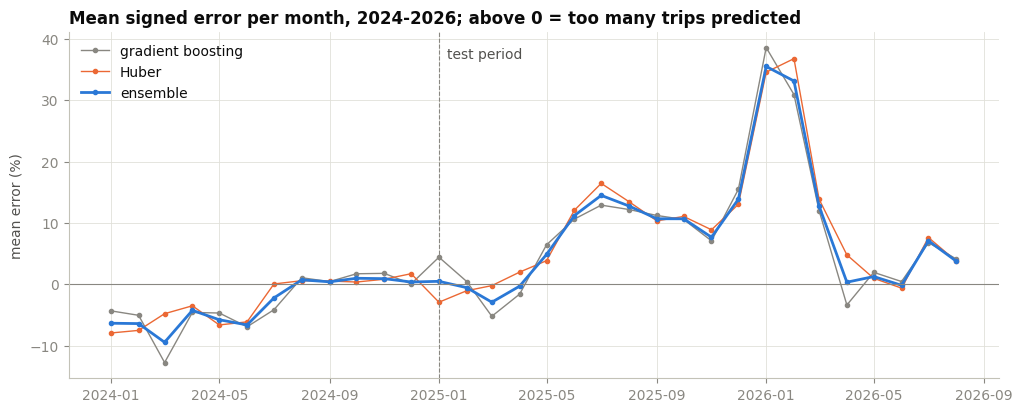

date,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
gradient boosting,-4.3,-5.0,-12.7,-4.6,-4.7,-6.9,-4.1,1.1,0.5,1.7,1.8,0.1,4.4,0.5,-5.2,-1.6,6.4,10.6,12.9,12.2,11.2,10.6,7.1,15.5,38.6,30.9,12.0,-3.4,2.0,0.5,6.8,4.1
Huber,-7.9,-7.5,-4.8,-3.5,-6.6,-6.1,0.1,0.6,0.5,0.4,0.8,1.7,-2.9,-1.0,-0.2,2.0,3.9,12.1,16.5,13.5,10.4,11.1,8.9,13.1,34.6,36.8,13.9,4.8,1.0,-0.6,7.6,3.8
ensemble,-6.3,-6.4,-9.4,-4.2,-5.8,-6.6,-2.2,0.7,0.4,1.0,0.9,0.4,0.5,-0.5,-2.9,-0.3,4.9,11.2,14.5,12.8,10.7,10.7,7.7,13.9,35.5,33.2,12.8,0.4,1.3,-0.2,7.1,3.8


In [7]:
hold_out = pd.concat([validation, test])


def monthly_bias(predicted, days):
    return ((predicted - days.total) / days.total * 100)[days.total > 0].resample("MS").mean()


bias = pd.DataFrame({name: monthly_bias(pd.Series(np.exp(model.predict(hold_out[columns])) * hold_out.level_12m,
                                                  index=hold_out.index), hold_out)
                     for name, (model, columns) in MEMBERS.items()})
bias["ensemble"] = monthly_bias(pd.concat(predictions.values()), hold_out)
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, colour, width in [("gradient boosting", INK_MUTED, 1.0), ("Huber", ORANGE, 1.0), ("ensemble", BLUE, 2.0)]:
    ax.plot(bias.index, bias[name], color=colour, marker="o", markersize=3, linewidth=width, label=name)
ax.axvline(pd.Timestamp("2025-01-01"), color=INK_MUTED, linewidth=0.8, linestyle="--")
ax.text(pd.Timestamp("2025-01-10"), bias.max().max(), "test period", color=INK_SECONDARY, va="top")
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("mean error (%)")
ax.set_title("Mean signed error per month, 2024-2026; above 0 = too many trips predicted", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()
bias.round(1).T

**Interpretation:** the ensemble's monthly error lies between those of its members almost every month, as an average must. Where the two members disagree, it is better than the worse one (March 2024: gradient boosting -12.7%, Huber -4.8%, ensemble -9.4%; February 2026: 30.9% and 36.8%, ensemble 33.2%). Where both drift in the same direction (June-December 2025, +8% to +15%; January 2026 about +35%), the ensemble drifts too.

## 7. Saving the model and the metrics

The fitted `VotingRegressor` is saved with `joblib`; it contains both members and needs only scikit-learn. The JSON file lists the input columns (the union of both members' columns) and the weights.

In [8]:
joblib.dump(ensemble, MODEL_PATH, compress=3)
reloaded = joblib.load(MODEL_PATH)
assert np.allclose(reloaded.predict(test[INPUT_COLUMNS]), ensemble.predict(test[INPUT_COLUMNS]))
description = {
    "model": "citibike_ensemble", "notebook": NOTEBOOK,
    "estimator": "VotingRegressor of citibike_gradient_boosting (05a) and citibike_huber (05b)",
    "weights": {"gradient_boosting": float(WEIGHT), "huber": float(round(1 - WEIGHT, 1))},
    "input_columns": INPUT_COLUMNS, "categorical_columns": ["weekday", "month", "precipitation"],
    "missing_values_allowed": ["wind_ms"],
    "output": "log(demand_ratio); predicted trips = exp(output) * level_12m",
    "level_12m": DATASET["level_definition"],
    "validation": {key: round(float(value), 2) for key, value in results[0].items() if key in ("mae", "mape", "bias_pct")},
}
with open(MODEL_PATH.with_suffix(".json"), "w", encoding="utf-8") as file:
    json.dump(description, file, indent=2)
print(f"saved {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.0f} KB) and {MODEL_PATH.with_suffix('.json').name}")

metrics = pd.read_csv(METRICS_PATH)
metrics = pd.concat([metrics[metrics.notebook != NOTEBOOK], pd.DataFrame(results)], ignore_index=True)
metrics.to_csv(METRICS_PATH, index=False)
metrics.drop(columns="notebook").round(1)

saved models\citibike_ensemble.joblib (557 KB) and citibike_ensemble.json


,model,split,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
0,PyCaret blend gbr + rf + lightgbm,validation,366,9657.7,12700.3,9.5,6.3,88.5,-3.1
1,PyCaret blend gbr + rf + lightgbm,test,607,13806.2,17529.1,14.6,9.8,80.9,8.6
2,seasonal naive,validation,366,17755.7,24079.1,22.2,10.9,71.9,5.2
3,linear regression (baseline),validation,366,12787.4,16669.8,12.4,9.7,82.2,-4.2
4,seasonal naive,test,607,24128.1,32296.4,38.0,14.7,61.9,31.6
5,linear regression (baseline),test,607,17205.9,22335.4,17.4,11.9,73.6,7.8
6,gradient boosting (05a),validation,366,9499.5,12207.3,9.6,6.4,86.1,-3.1
7,gradient boosting (05a),test,607,14577.8,18235.1,15.1,10.4,80.0,8.8
8,Huber regression (05b),validation,366,11645.3,15293.6,10.8,8.7,88.3,-2.7
9,Huber regression (05b),test,607,15837.4,20535.3,15.7,11.2,77.9,9.4


## 8. Conclusion and next steps

- **Model:** a `VotingRegressor` that averages the tuned gradient boosting of 05a and the Huber regression of 05b with equal weights (chosen on the folds). Validation MAPE 9.3% and 90.2% of the days within 20% (both the best so far), test MAPE 14.4% (the best so far). Saved as `models/citibike_ensemble.joblib` (557 KB, scikit-learn only) with its JSON description.
- **Why it works:** the two members make partly different errors (correlation 0.68), so averaging cancels part of them; any mix between 40% and 60% gradient boosting is about equally good.
- **What did not work:** correcting the predictions by the recent monthly error. A month's error is mostly that month's weather and repeats only weakly (correlation 0.37), so the correction adds noise.
- **Open:** in trips (MAE) gradient boosting alone and PyCaret's blend are slightly better; the drift (+8.8% bias on the test period) is unchanged.

**Next steps:** `07_model_comparison.ipynb` compares all models on the validation year with uncertainty (the days of a year are not independent, so with a block bootstrap), weighs accuracy against size, speed and explainability, and chooses the deployed model. `06` (AWS) is still to be built.